# MusicBox Basic Workflow Tutorial

Hello, and welcome to the MusicBox basic workflow tutorial! Here, we will be covering some basic usages of the MusicBox library.

## What is MusicBox?

MusicBox is a library with a Python API for box modeling that builds on top of musica, a collection of modeling software that allows for robust modeling of chemistry in Earth's atmosphere.

Boxes refer to a set of adjacent grid cells that represent the exchange of information.

## 1. Creating a Conda Environment (Optional)

Before getting started, make sure your Python version is 3.10 or higher. You can optionally set up a conda environment. If you prefer to use an existing Python 3.10+ environment, you can skip to step 2.

To create a new conda environment, execute these commands in your terminal:

```
conda create --name music_box python=3.13
conda activate music_box
```

## 2. Downloading MusicBox

To install MusicBox onto your device, run this tutorial

```
pip install acom_music_box[tutorial] #bash
pip install 'acom_music_box[tutorial]' #zsh
```

<b>Note:</b> Installing MusicBox will automatically install musica, a required dependency of MusicBox that is used throughout this tutorial.

## 3. Importing MusicBox

To import your newly-downloaded MusicBox into a Python file, as well as some other libraries so that this demo can run:

In [1]:
from acom_music_box import MusicBox
import musica.mechanism_configuration as mc
import matplotlib.pyplot as plt

This code cell may take upwards of 2 minutes to run on the first execution depending on your system, so do not fret if it feels a bit sluggish at first.

## 4. Defining a System

In MusicBox, a system is defined by a mechanism that includes:
* a set of species and their respective phases, and
* a set of reactions that the species participate in.

The system is the fundamental building block of MusicBox and is your main concern when using this library.

The following steps will walk you through:
* creating your own system,
* solving your system, and
* viewing and visualizing your results.

### 4a. Defining Species

A species is simply a reactant or product in a chemical reaction.

You have the freedom to name a species anything in MusicBox, just make sure that it is logical to you.

For extended documentation about the Species class, go [here](https://ncar-musica.readthedocs.io/en/latest/api/python.html#musica.mechanism_configuration.Species).

Here is a snippet that defines three chemical species:

In [2]:
# Create each of the species that will be simulated and gas phase
X = mc.Species(name="X")
Y = mc.Species(name="Y")
Z = mc.Species(name="Z")
species = {"X": X, "Y": Y, "Z": Z}
gas = mc.Phase(name="gas", species=list(species.values()))

This code block creates 3 species called X, Y, and Z and adds them to a dictionary called species.

The variable name and the name of the species are not required to be the same, but it is strongly recommended so that your code is more organized.

Next, a phase is created named "gas". In MusicBox, phases are essentially collections of species that are assumed to be well-mixed.

**Note:** Creating the species dictionary and the phase is mandatory, as subsequent code relies on the data being bundled in specific object types.

### 4b. Defining Reactions

A chemical reaction is a process in which a set of reactants transforms into a set of products.

To define a reaction in MusicBox:

In [3]:
# Define the Arrhenius reactions
arr1 = mc.Arrhenius(name="X->Y", A=4.0e-3, C=50, reactants=[species["X"]], products=[species["Y"]], gas_phase=gas)
arr2 = mc.Arrhenius(name="Y->Z", A=4.0e-3, C=50, reactants=[species["Y"]], products=[species["Z"]], gas_phase=gas)
rxns = {"X->Y": arr1, "Y->Z": arr2}

This code block uses the gas and species variables from the previous code block.

Using the species and gas variables, it creates two reactions: arr1 and arr2.

The arr1 variable represents the conversion of X (reactant) into Y (product) and defines Arrhenius rate constant parameters:
* **A**: Pre-exponential factor (4.0e-3 in this example)
* **C**: Temperature coefficient (50 in this example)

The arr2 variable is just like arr1, but instead it represents the conversion of Y (reactant) into Z (product).

These reactions are then bundled into a dictionary called rxns just like the species before.

More information on the Arrhenius reaction can be found [here](https://mechanismconfiguration.readthedocs.io/en/latest/v1/reactions/arrhenius.html).

**Note:** MusicBox allows for users to experiment with an array of reaction types.

Go [here](https://mechanismconfiguration.readthedocs.io/en/latest/v1/reactions/index.html) to view a list of supported reactions and their parameters.

### 4c. Defining Mechanisms

A mechanism represents a set of species with their respective phases and reactions.

For extended documentation about the Mechanism class, go [here](https://ncar-musica.readthedocs.io/en/latest/user_guide/python/chemistry/index.html#mechanisms).

To create a mechanism in MusicBox:

In [4]:
# Create the mechanism that is defined by the species, phases, and reactions
mechanism = mc.Mechanism(name="tutorial_mechanism", species=list(species.values()), phases=[gas], reactions=list(rxns.values()))

This code block builds upon the previous two functions, using the previously-created species, phases, and reactions as arguments.

It simply creates a mechanism variable that represents an instance of the Mechanism class.

The mechanism is first given a name, then the species, phase, and reactions are passed into their respective arguments.

## 5. Creating a Box Model

Box models allow you to solve your previously-created mechanism under conditions that can change the reactions' rates over time.

Each instance of the MusicBox class acts as an independent box model.

You can also define the length of the simulations and the time steps.

To initialize a new box model:

In [5]:
# Create the box model that contains the mechanism
box_model = MusicBox()
box_model.load_mechanism(mechanism)

This code block is straightforward, simply creating an instance of the MusicBox class and then loading the mechanism as an argument for the box model.

### 5a. Adding Initial Conditions to Your Box Model

The initial conditions of the model define the environment the mechanism takes place in at the start of the simulation.

Some conditions that are recommended to define for your system include:
* the temperature, measured in Kelvin (K),
* the pressure, measured in Pascals (Pa), and
* the concentration of each of the species, measured in mol/m³.

To set the initial conditions of your box model, use the `set_condition()` method with `time=0`:

In [6]:
# Set the conditions of the box model at time = 0 s
box_model.set_condition(
    time=0,
    temperature=298.15,  # Units: Kelvin (K)
    pressure=101325.0,   # Units: Pascals (Pa)
    concentrations={     # Units: mol/m^3
        "X": 3.75,
        "Y": 5.0,
        "Z": 2.5,
    }
)

You provide a time value (0 for initial conditions), along with temperature, pressure, and each of the species' concentrations as keyword arguments. Air density is optional (by default it's calculated using the Ideal Gas Law).

### 5b. Adding Evolving Conditions to Your Box Model

Evolving conditions allow you to change the environment of the mechanism at specific time points.

These changes can include species concentration, temperature, pressure, etc.

To create evolving conditions for your box model, use the same `set_condition()` method with a different time value:

In [7]:
# Set the box model conditions at the defined time
box_model.set_condition(
    time=100.0,         # Units: Seconds (s)
    temperature=275.0,  # Units: Kelvin (K)
    pressure=100100.0   # Units: Pascals (Pa)
)

This code block is similar to setting the initial conditions, but uses a different time value.

The `set_condition()` method is called again with `time=100.0` to specify that these conditions (temperature and pressure changes) should take effect at 100 seconds into the simulation.

You can call `set_condition()` multiple times with different time values to create a sequence of environmental changes throughout your simulation.

### 5c. Additional Box Model Configuration

Box models contain some additional configuration options that need to be defined.

These include:
* the simulation length,
* the chemistry step time, and
* the output step time.

To set these configurations for your box model:

In [8]:
# Set the additional configuration options for the box model
box_model.box_model_options.simulation_length = 200 # Units: Seconds (s)
box_model.box_model_options.chem_step_time = 1      # Units: Seconds (s)
box_model.box_model_options.output_step_time = 20   # Units: Seconds (s)

This code block sets some of the attributes of the box model's options, including:

* **simulation_length:** the total duration of the simulation (in seconds),
* **chem_step_time:** the time interval between each chemistry calculation (in seconds), and
* **output_step_time:** the time interval between each output data point (in seconds).

All three of these use seconds as their unit.

## 6. Solving Your Box Model

Now, you are able to run and solve your newly-created box model.

To solve your box model, simply call its `solve()` function:

In [9]:
df = box_model.solve()

The `solve()` method returns a pandas DataFrame containing the simulation results.

## 7. View Outputs and Visualizations
The DataFrame includes the following columns:

* **time.s** - Simulation time in seconds
* **ENV.temperature.K** - Temperature at each time step in Kelvin
* **ENV.pressure.Pa** - Pressure at each time step in Pascals
* **ENV.air number density.mol m-3** - Air density in mol/m³
* **CONC.X.mol m-3**, **CONC.Y.mol m-3**, **CONC.Z.mol m-3** - Species concentrations in mol/m³ for each species in your mechanism

This structured format makes it easy to analyze, visualize, and export your simulation results.

To view your solved model's data and a basic visualization of it:

,time.s,ENV.temperature.K,ENV.pressure.Pa,ENV.air number density.mol m-3,CONC.X.mol m-3,CONC.Y.mol m-3,CONC.Z.mol m-3
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,100.000000,287.627273,100768.181818,42.194541,2.439584,4.194061,4.616355
std,66.332496,12.089693,639.735386,1.517135,0.762650,0.572226,1.329958
min,0.000000,275.000000,100100.000000,40.874045,1.446236,3.306276,2.500000
25%,50.000000,275.000000,100100.000000,40.874045,1.840420,3.761719,3.640977
50%,100.000000,298.150000,101325.000000,40.874045,2.336660,4.220865,4.692475
75%,150.000000,298.150000,101325.000000,43.779137,2.963461,4.645562,5.647861
max,200.000000,298.150000,101325.000000,43.779137,3.750000,5.000000,6.497488


,time.s,ENV.temperature.K,ENV.pressure.Pa,ENV.air number density.mol m-3,CONC.X.mol m-3,CONC.Y.mol m-3,CONC.Z.mol m-3
0,0.0,298.15,101325.0,40.874045,3.750000,5.000000,2.500000
1,20.0,298.15,101325.0,40.874045,3.411490,4.871403,2.967107
2,40.0,298.15,101325.0,40.874045,3.103538,4.725280,3.421182
3,60.0,298.15,101325.0,40.874045,2.823383,4.565844,3.860773
4,80.0,298.15,101325.0,40.874045,2.568519,4.396687,4.284794
5,100.0,298.15,101325.0,40.874045,2.336660,4.220865,4.692475
6,120.0,275.00,100100.0,43.779137,2.122874,4.038383,5.088743
7,140.0,275.00,100100.0,43.779137,1.928648,3.853960,5.467392
8,160.0,275.00,100100.0,43.779137,1.752192,3.669479,5.828329
9,180.0,275.00,100100.0,43.779137,1.591880,3.486494,6.171626


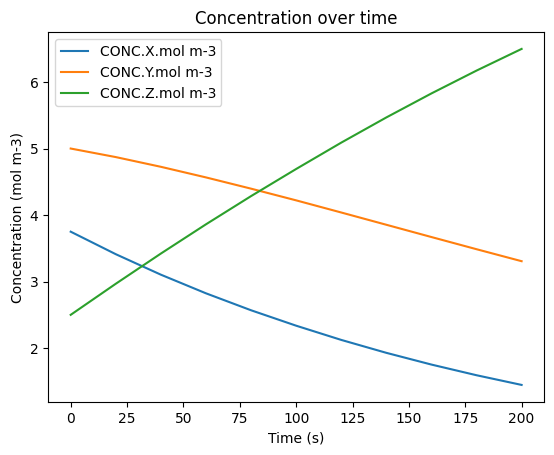

In [10]:
display(df.describe())
display(df)
df.plot(x='time.s', y=['CONC.X.mol m-3', 'CONC.Y.mol m-3', 'CONC.Z.mol m-3'], title='Concentration over time', ylabel='Concentration (mol m-3)', xlabel='Time (s)')
plt.show()

The first `display()` call shows statistical summary information about the DataFrame (count, mean, standard deviation, min/max values).

The second `display()` shows the full DataFrame with all time steps and their corresponding values.

The `plot()` function from pandas creates a line plot visualization:
* **x='time.s'** - Sets time as the x-axis
* **y=[...]** - Lists the species concentrations to plot on the y-axis
* **title, xlabel, ylabel** - Add labels to make the plot readable

The `plt.show()` displays the plot in the notebook.

**Note:** If you are running this code in a Jupyter notebook, use `display()` as shown above. If you're running this as a Python script in a terminal, replace `display()` with `print()`.